# Продакшн data-пайплайны: за пределами первого DAG

Мы уже разбирали [DWH, Data Lake, Lakehouse и Data Mesh](1.ipynb) и собрали первый DAG в Airflow
(операторы, таски, `>>`). Этого достаточно, чтобы DAG *запустился*. Но чтобы пайплайн пережил
продакшн — нужно на порядок больше: он должен переживать перезапуски, падения источника,
повторные ручные запуски и не плодить дубли данных.

В этой лекции — то, что обычно остаётся "за кадром" вводного курса по Airflow:

1. Execution date / data interval, `catchup`, backfill
2. Идемпотентность и инкрементальная загрузка (watermark)
3. Slowly Changing Dimensions: Type 1 vs Type 2
4. Паттерны зависимостей: branching, trigger rules, sensors
5. Data quality gate как часть пайплайна
6. **Практика**: пишем мини-движок DAG и прогоняем на нём реалистичный пайплайн
7. Retries, backoff, alerting, SLA
8. Airflow + dbt: разделение оркестрации и трансформации
9. Data-aware scheduling: `Dataset` вместо cron
10. Важные выводы
11. Задания для практики

Практическая часть работает с **настоящим PostgreSQL** в Docker (тот же контейнер
`tutor-pg-optimization`, что и в [`sql/query_optimization_postgres.ipynb`](../sql/query_optimization_postgres.ipynb),
но отдельная база `pipelines`) — через `psycopg2`, реальные `INSERT ... ON CONFLICT`,
реальные транзакции. Простые Python-функции здесь — это не замена Airflow, а способ
увидеть *механику* (идемпотентность, retries, trigger rules) без развёртывания
scheduler + webserver + metadata DB ради одного ноутбука.

## Подключение к PostgreSQL

Используем контейнер `tutor-pg-optimization` (`127.0.0.1:5433`), базу `pipelines`
(создана отдельно от `optimization`, чтобы не мешать данным из ноутбука про оптимизацию запросов).

In [1]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from dataclasses import dataclass, field
from enum import Enum
from datetime import datetime, date, timedelta
import time
import random

random.seed(42)
np.random.seed(42)
pd.set_option("display.max_colwidth", 120)

conn = psycopg2.connect(host="127.0.0.1", port=5433, user="tutor", password="tutor", dbname="pipelines")
conn.autocommit = True
cur = conn.cursor()
print("Подключено к базе:", conn.get_dsn_parameters()["dbname"])

Подключено к базе: pipelines


**Почему `autocommit = True`, а не одна большая транзакция на весь пайплайн?** В реальном
Airflow каждый таск — это отдельный процесс (иногда в отдельном контейнере), который может
писать в источник и приёмник, находящиеся в разных базах или даже разных системах (Kafka → S3,
Postgres → Snowflake). Обернуть весь пайплайн в одну SQL-транзакцию физически невозможно.
Атомарность на уровне всего пайплайна обеспечивается не транзакцией, а **идемпотентностью**
каждого шага: если таск упал на середине — его просто безопасно перезапускают.

In [2]:
cur.execute("""
DROP TABLE IF EXISTS gold_customer_orders, dim_customers, target_orders, source_orders, pipeline_state CASCADE
""")

cur.execute("""
CREATE TABLE source_orders (
    order_id    INTEGER PRIMARY KEY,
    customer_id INTEGER,
    amount      NUMERIC(10,2),
    updated_at  TIMESTAMP NOT NULL
)
""")

cur.execute("""
CREATE TABLE target_orders (
    order_id    INTEGER PRIMARY KEY,
    customer_id INTEGER NOT NULL,
    amount      NUMERIC(10,2) NOT NULL,
    updated_at  TIMESTAMP NOT NULL
)
""")

cur.execute("""
CREATE TABLE pipeline_state (
    pipeline_name TEXT PRIMARY KEY,
    watermark     TIMESTAMP NOT NULL
)
""")

cur.execute("""
CREATE TABLE dim_customers (
    customer_key SERIAL PRIMARY KEY,
    customer_id  INTEGER NOT NULL,
    region       TEXT NOT NULL,
    segment      TEXT NOT NULL,
    valid_from   DATE NOT NULL,
    valid_to     DATE,
    is_current   BOOLEAN NOT NULL DEFAULT TRUE
)
""")

cur.execute("""
CREATE TABLE gold_customer_orders (
    region      TEXT NOT NULL,
    order_month DATE NOT NULL,
    revenue     NUMERIC(12,2) NOT NULL,
    orders_cnt  INTEGER NOT NULL,
    PRIMARY KEY (region, order_month)
)
""")

# начальное состояние измерения клиентов (5 клиентов, актуальные на 2026-01-01)
seed_date = date(2026, 1, 1)
customers_seed = [
    (1, "North", "retail"),
    (2, "South", "retail"),
    (3, "East", "wholesale"),
    (4, "West", "retail"),
    (5, "North", "wholesale"),
]
for customer_id, region, segment in customers_seed:
    cur.execute(
        "INSERT INTO dim_customers (customer_id, region, segment, valid_from, valid_to, is_current) "
        "VALUES (%s, %s, %s, %s, NULL, TRUE)",
        (customer_id, region, segment, seed_date),
    )

print("Схема создана, dim_customers засеяна:", len(customers_seed), "клиентов")

Схема создана, dim_customers засеяна: 5 клиентов


## 1. Execution date / data interval, catchup, backfill

Самая частая путаница у новичков в Airflow: DAG со `schedule="@daily"`, у которого запуск
**появившийся на экране 2 января**, на самом деле обрабатывает данные **за 1 января**.

Причина — Airflow планирует не "текущий момент", а **интервал данных**
(`data_interval_start` … `data_interval_end`), а сам прогон стартует только когда этот интервал
уже полностью завершился. Раньше это поле называлось `execution_date` — то же самое, только
менее удачное имя (звучит как "когда запустится", а означает "какой период обрабатывает").

* **`catchup=True`** (по умолчанию) — если `start_date` в прошлом, Airflow создаст и выполнит
  **все** пропущенные интервалы вплоть до текущего момента ("автоматический backfill" при первом включении DAG)
* **`catchup=False`** — выполнится только самый последний интервал, прошлое игнорируется
* **Ручной backfill** (`airflow dags backfill -s ... -e ...`) — намеренный пересчёт диапазона
  дат задним числом, например, после того как в коде трансформации нашли и исправили баг

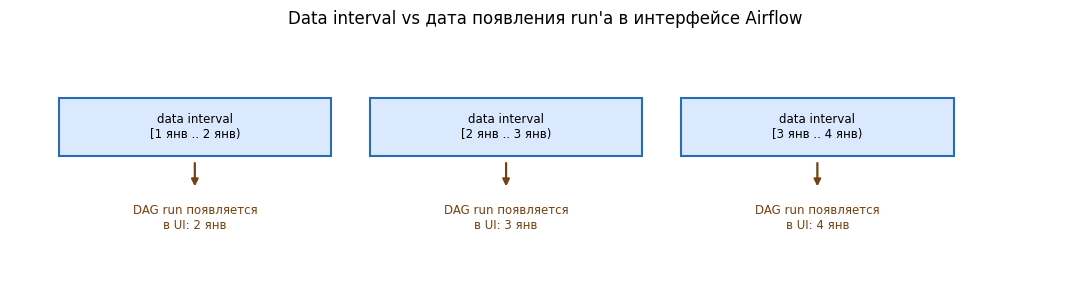

In [ ]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.set_xlim(0, 11)
ax.set_ylim(0, 3)
ax.axis("off")

days = ["1 янв", "2 янв", "3 янв", "4 янв"]
for i, d in enumerate(days[:-1]):
    x0 = 0.5 + i * 3.2
    rect = plt.Rectangle((x0, 1.5), 2.8, 0.7, facecolor="#dbe9ff", edgecolor="#2b6cb0", linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x0 + 1.4, 1.85, f"data interval\n[{days[i]} .. {days[i+1]})", ha="center", va="center", fontsize=8.5)
    ax.annotate("", xy=(x0 + 1.4, 1.1), xytext=(x0 + 1.4, 1.45),
                arrowprops=dict(arrowstyle="-|>", color="#744210", linewidth=1.6))
    ax.text(x0 + 1.4, 0.75, f"DAG run появляется\nв UI: {days[i+1]}", ha="center", va="center",
            fontsize=8.5, color="#744210")

ax.set_title("Data interval vs дата появления run'а в интерфейсе Airflow", fontsize=12)
plt.tight_layout()
plt.show()

## 2. Идемпотентность и инкрементальная загрузка (watermark)

**Идемпотентный** таск — такой, что при повторном запуске с теми же входными данными
результат не меняется (данные не дублируются, не портятся). Это свойство №1, без которого
пайплайн не переживёт продакшн: таски *будут* падать и перезапускаться — вопрос только когда.

Два паттерна, которые вместе дают идемпотентность инкрементальной загрузки:

1. **Watermark** — храним "до какого момента данные уже точно загружены" (обычно в отдельной
   таблице состояния, как `pipeline_state` ниже — не в файле на диске воркера, который может
   быть эфемерным). Каждый запуск читает из источника только строки `updated_at > watermark`.
2. **UPSERT при загрузке** (`INSERT ... ON CONFLICT DO UPDATE`) вместо слепого `INSERT`/`append`.
   Тогда даже если один и тот же батч случайно обработают дважды — строки просто перезапишутся
   теми же значениями, а не задублируются.

Важно: **watermark обновляется только после успешной загрузки** — если таск упал на середине,
при перезапуске он снова увидит старый watermark и повторно (безопасно, благодаря UPSERT)
обработает тот же батч.

In [4]:
def get_watermark(pipeline_name: str) -> datetime:
    cur.execute("SELECT watermark FROM pipeline_state WHERE pipeline_name = %s", (pipeline_name,))
    row = cur.fetchone()
    return row[0] if row else datetime(1970, 1, 1)


def set_watermark(pipeline_name: str, value: datetime) -> None:
    cur.execute(
        "INSERT INTO pipeline_state (pipeline_name, watermark) VALUES (%s, %s) "
        "ON CONFLICT (pipeline_name) DO UPDATE SET watermark = EXCLUDED.watermark",
        (pipeline_name, value),
    )


def extract_incremental_orders(pipeline_name: str = "orders_pipeline"):
    wm = get_watermark(pipeline_name)
    cur.execute(
        "SELECT order_id, customer_id, amount, updated_at FROM source_orders "
        "WHERE updated_at > %s ORDER BY updated_at",
        (wm,),
    )
    rows = cur.fetchall()
    df = pd.DataFrame(rows, columns=["order_id", "customer_id", "amount", "updated_at"])
    return df, wm


def load_orders_upsert(df: pd.DataFrame, pipeline_name: str = "orders_pipeline") -> None:
    if df.empty:
        return
    for row in df.itertuples(index=False):
        cur.execute(
            "INSERT INTO target_orders (order_id, customer_id, amount, updated_at) "
            "VALUES (%s, %s, %s, %s) "
            "ON CONFLICT (order_id) DO UPDATE SET "
            "customer_id = EXCLUDED.customer_id, amount = EXCLUDED.amount, updated_at = EXCLUDED.updated_at",
            (row.order_id, row.customer_id, float(row.amount), row.updated_at),
        )
    set_watermark(pipeline_name, df["updated_at"].max())

Проверим на практике: "день 1" — 500 новых заказов в источнике.

In [5]:
day1 = datetime(2026, 1, 5, 12, 0)

rows = [
    (i, random.randint(1, 5), round(random.uniform(10, 500), 2), day1)
    for i in range(1, 501)
]
cur.executemany(
    "INSERT INTO source_orders (order_id, customer_id, amount, updated_at) VALUES (%s, %s, %s, %s)",
    rows,
)

df, wm_before = extract_incremental_orders()
print(f"Watermark до: {wm_before}, извлечено строк: {len(df)}")
load_orders_upsert(df)

cur.execute("SELECT COUNT(*) FROM target_orders")
print(f"Строк в target_orders: {cur.fetchone()[0]}")
print(f"Новый watermark: {get_watermark('orders_pipeline')}")

Watermark до: 1970-01-01 00:00:00, извлечено строк: 500


Строк в target_orders: 500
Новый watermark: 2026-01-05 12:00:00


In [6]:
# --- Повторный запуск СРАЗУ ЖЕ, без новых данных в источнике ---
df_rerun, wm_before_rerun = extract_incremental_orders()
print(f"Watermark до: {wm_before_rerun}, извлечено строк при повторном запуске: {len(df_rerun)}")
load_orders_upsert(df_rerun)

cur.execute("SELECT COUNT(*) FROM target_orders")
print(f"Строк в target_orders после повторного запуска: {cur.fetchone()[0]} (дублей нет)")

Watermark до: 2026-01-05 12:00:00, извлечено строк при повторном запуске: 0
Строк в target_orders после повторного запуска: 500 (дублей нет)


Ноль новых строк — как и должно быть: watermark уже на уровне `day1`, повторный запуск —
это no-op. Теперь смоделируем реальный день 2: часть старых заказов **обновилась**
(например, служба поддержки скорректировала сумму), плюс появились новые заказы.

In [7]:
day2 = datetime(2026, 1, 6, 12, 0)

# коррекция суммы у 10 уже загруженных заказов
correction_ids = list(range(1, 11))
for order_id in correction_ids:
    cur.execute(
        "UPDATE source_orders SET amount = amount + 100, updated_at = %s WHERE order_id = %s",
        (day2, order_id),
    )

# новые заказы дня 2
new_rows = [
    (i, random.randint(1, 5), round(random.uniform(10, 500), 2), day2)
    for i in range(501, 701)
]
cur.executemany(
    "INSERT INTO source_orders (order_id, customer_id, amount, updated_at) VALUES (%s, %s, %s, %s)",
    new_rows,
)

df_day2, wm_before_day2 = extract_incremental_orders()
print(f"Watermark до: {wm_before_day2}, извлечено строк за день 2: {len(df_day2)} "
      f"(ожидаем {len(correction_ids)} обновлённых + {len(new_rows)} новых = {len(correction_ids) + len(new_rows)})")

load_orders_upsert(df_day2)

cur.execute("SELECT COUNT(*) FROM target_orders")
total = cur.fetchone()[0]
cur.execute("SELECT amount FROM target_orders WHERE order_id = 1")
corrected_amount = cur.fetchone()[0]
print(f"Строк в target_orders: {total} (было 500, стало 500 + 200 новых = 700, без дублей)")
print(f"Скорректированная сумма заказа #1: {corrected_amount}")

Watermark до: 2026-01-05 12:00:00, извлечено строк за день 2: 210 (ожидаем 10 обновлённых + 200 новых = 210)


Строк в target_orders: 700 (было 500, стало 500 + 200 новых = 700, без дублей)
Скорректированная сумма заказа #1: 122.26


Watermark, основанный на `updated_at`, корректно поймал и **обновления** старых строк,
и **новые** строки — а `ON CONFLICT DO UPDATE` гарантировал, что заказ #1 не задублировался,
а просто получил новую сумму. Это стандартный паттерн инкрементального ETL/ELT в реальных
пайплайнах (часто называется CDC — Change Data Capture, когда `updated_at` берётся не вручную,
а из триггеров/WAL источника).

## 3. Slowly Changing Dimensions: Type 1 vs Type 2

В [прошлой лекции](1.ipynb) мы строили звёздную схему с измерением `dim_customer`. Но что
делать, если атрибут клиента **меняется** — например, клиент переехал в другой регион?
Это классическая задача **SCD (Slowly Changing Dimensions)**:

* **Type 1 — перезаписать.** Простое `UPDATE`. История теряется: если посмотреть на старые
  факты (заказы) через текущее измерение, покажется, что клиент *всегда* жил в новом регионе.
  Подходит, когда история изменений атрибута не важна для аналитики (например, опечатка в имени).
* **Type 2 — версионировать.** Старая строка помечается закрытой (`valid_to`, `is_current=False`),
  и добавляется новая строка с `valid_from` от даты изменения. История сохраняется: можно
  посчитать "выручка по региону *на момент совершения заказа*", а не "по текущему региону клиента".

In [8]:
def apply_scd1(customer_id: int, new_region: str, new_segment: str) -> None:
    cur.execute(
        "UPDATE dim_customers SET region = %s, segment = %s "
        "WHERE customer_id = %s AND is_current",
        (new_region, new_segment, customer_id),
    )


def apply_scd2(customer_id: int, new_region: str, new_segment: str, change_date: date) -> bool:
    """Возвращает True, если атрибуты реально изменились (и была создана новая версия)."""
    cur.execute(
        "SELECT region, segment FROM dim_customers WHERE customer_id = %s AND is_current",
        (customer_id,),
    )
    current = cur.fetchone()
    if current == (new_region, new_segment):
        return False

    cur.execute(
        "UPDATE dim_customers SET valid_to = %s, is_current = FALSE "
        "WHERE customer_id = %s AND is_current",
        (change_date, customer_id),
    )
    cur.execute(
        "INSERT INTO dim_customers (customer_id, region, segment, valid_from, valid_to, is_current) "
        "VALUES (%s, %s, %s, %s, NULL, TRUE)",
        (customer_id, new_region, new_segment, change_date),
    )
    return True

In [9]:
change_date = date(2026, 1, 10)

# клиент #2 (Type 1): регион просто перезаписывается, истории не остаётся
apply_scd1(customer_id=2, new_region="East", new_segment="retail")

# клиент #3 (Type 2): регион меняется с сохранением истории
changed = apply_scd2(customer_id=3, new_region="West", new_segment="wholesale", change_date=change_date)
print(f"Клиент #3: атрибуты изменились и создана новая версия: {changed}")

dim = pd.read_sql(
    "SELECT customer_id, region, segment, valid_from, valid_to, is_current "
    "FROM dim_customers WHERE customer_id IN (2, 3) ORDER BY customer_id, valid_from",
    conn,
)
dim

Клиент #3: атрибуты изменились и создана новая версия: True


C:\Users\raven\AppData\Local\Temp\ipykernel_31972\1090928740.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dim = pd.read_sql(


,customer_id,region,segment,valid_from,valid_to,is_current
0,2,East,retail,2026-01-01,None,True
1,3,East,wholesale,2026-01-01,2026-01-10,False
2,3,West,wholesale,2026-01-10,None,True


У клиента **#2** (Type 1) — по-прежнему одна строка, старое значение региона потеряно
безвозвратно. У клиента **#3** (Type 2) — теперь две строки: закрытая (`is_current=False`,
`valid_to` проставлен) и новая актуальная. Джойн `fact_sales` с `dim_customers` "как есть"
для Type 2 обычно делают не по `customer_id`, а по суррогатному `customer_key` **и**
диапазону дат (`order_date BETWEEN valid_from AND valid_to`), чтобы факты попадали к той
версии измерения, которая была актуальна *на момент события*.

## 4. Паттерны зависимостей: branching, trigger rules, sensors

Реальные DAG редко бывают линейной цепочкой `t1 >> t2 >> t3`. Вот паттерны, которые
понадобятся почти в любом продакшн-пайплайне (код ниже — **синтаксис настоящего Airflow**,
для справки; он не выполняется в этом ноутбуке, так как отдельный scheduler+webserver
разворачивать здесь бессмысленно — механику мы разберём на собственном движке в разделе 6):

**Fan-out / fan-in** — несколько независимых веток из одной точки и обратно:
```python
extract >> [transform_orders, transform_customers] >> load
```

**Branching** — выбор одной из веток в зависимости от условия:
```python
from airflow.operators.python import BranchPythonOperator

def choose_branch(**context):
    if context["logical_date"].day == 1:
        return "monthly_aggregation"
    return "skip_monthly"

branch = BranchPythonOperator(task_id="branch", python_callable=choose_branch)
branch >> [monthly_aggregation, skip_monthly]
```

**Trigger rules** — по умолчанию таск запускается, только если *все* родители завершились
успешно (`all_success`). Это не подходит для тасков очистки/уведомлений — они должны отработать
**в любом случае**:
```python
notify = PythonOperator(task_id="notify", python_callable=send_slack_alert,
                         trigger_rule="all_done")   # запустится, даже если upstream упал
```
Другие частые правила: `one_failed` (запустить именно потому, что что-то упало — например,
таск отправки алерта), `none_failed_min_one_success`.

**Sensors** — ждут внешнего условия перед стартом, например, что другая команда (другой домен
в терминах Data Mesh из [прошлой лекции](1.ipynb)) выложила свежий файл:
```python
from airflow.sensors.filesystem import FileSensor

wait_for_upstream = FileSensor(task_id="wait_for_upstream_domain",
                                filepath="/data/upstream_domain/_SUCCESS",
                                poke_interval=60, timeout=3600)
```

## 5. Data quality gate как часть пайплайна

В прошлой лекции для Data Mesh мы писали `DataProductContract` и `validate_data_product` —
явную, проверяемую машиной проверку данных. В реальном пайплайне это оформляется как
**отдельный таск между extract и load**: если данные не прошли проверку — пайплайн **должен
упасть до того, как испортит `target`/`gold`**, а не молча протащить мусор дальше.

В продакшне для этого обычно используют не самописный код, а готовые фреймворки:
**Great Expectations**, **Soda**, или тесты `dbt` (`dbt test`). Идея та же — здесь напишем
минимальную версию сами, чтобы увидеть механику.

In [10]:
def validate_orders_batch(df: pd.DataFrame) -> list[str]:
    issues = []
    if df.empty:
        return issues  # пустой батч (нет новых данных) — это не ошибка

    if df["order_id"].duplicated().any():
        issues.append("найдены дублирующиеся order_id внутри батча")
    if df["customer_id"].isna().any():
        issues.append("есть строки с NULL customer_id")
    if (df["amount"].astype(float) <= 0).any():
        bad = int((df["amount"].astype(float) <= 0).sum())
        issues.append(f"есть {bad} заказ(ов) с amount <= 0")

    return issues

## 6. Практика: мини-движок DAG на реальном пайплайне

Соберём всё вместе: свой минимальный аналог Airflow-executor'а — с зависимостями,
топологической сортировкой, retries и trigger rules — и прогоним на нём пайплайн, который
реально читает/пишет в Postgres через функции из разделов 2, 3, 5.

In [11]:
class TaskState(Enum):
    SUCCESS = "success"
    FAILED = "failed"
    UPSTREAM_FAILED = "upstream_failed"


@dataclass
class Task:
    name: str
    func: callable
    depends_on: list = field(default_factory=list)
    retries: int = 0
    retry_delay: float = 0.15
    trigger_rule: str = "all_success"   # "all_success" | "all_done" | "one_failed"


class MiniDAG:
    def __init__(self, name: str):
        self.name = name
        self.tasks: dict[str, Task] = {}

    def add_task(self, task: Task) -> None:
        self.tasks[task.name] = task

    def _topological_order(self) -> list[str]:
        in_degree = {name: 0 for name in self.tasks}
        children = {name: [] for name in self.tasks}
        for name, task in self.tasks.items():
            for dep in task.depends_on:
                children[dep].append(name)
                in_degree[name] += 1

        queue = [name for name, deg in in_degree.items() if deg == 0]
        order = []
        while queue:
            current = queue.pop(0)
            order.append(current)
            for child in children[current]:
                in_degree[child] -= 1
                if in_degree[child] == 0:
                    queue.append(child)

        if len(order) != len(self.tasks):
            raise ValueError("В графе задач обнаружен цикл")
        return order

    def run(self, ctx: dict) -> dict:
        state: dict[str, TaskState] = {}
        ctx["_state"] = state

        for name in self._topological_order():
            task = self.tasks[name]
            dep_states = [state[d] for d in task.depends_on]

            if task.trigger_rule == "all_success":
                should_run = all(s == TaskState.SUCCESS for s in dep_states)
            elif task.trigger_rule == "one_failed":
                should_run = any(s in (TaskState.FAILED, TaskState.UPSTREAM_FAILED) for s in dep_states)
            else:  # all_done — запускается, как только родители завершились, независимо от исхода
                should_run = True

            if not should_run:
                state[name] = TaskState.UPSTREAM_FAILED
                print(f"  [{name}] ⏭️  SKIPPED (upstream_failed, trigger_rule={task.trigger_rule})")
                continue

            attempt = 0
            while True:
                attempt += 1
                try:
                    task.func(ctx)
                    state[name] = TaskState.SUCCESS
                    break
                except Exception as e:
                    print(f"  [{name}] ❌ попытка {attempt}/{task.retries + 1} упала: {e}")
                    if attempt > task.retries:
                        state[name] = TaskState.FAILED
                        break
                    time.sleep(task.retry_delay)

        return state

Теперь опишем сами таски пайплайна — обёртки над функциями из разделов 2, 3, 5 — и соберём
из них DAG: `extract → quality_gate → {scd2_customers, load} → refresh_gold → notify`.

In [12]:
def refresh_gold(ctx: dict) -> None:
    cur.execute("""
        INSERT INTO gold_customer_orders (region, order_month, revenue, orders_cnt)
        SELECT dc.region,
               date_trunc('month', t.updated_at)::date AS order_month,
               SUM(t.amount),
               COUNT(*)
        FROM target_orders t
        JOIN dim_customers dc ON dc.customer_id = t.customer_id AND dc.is_current
        GROUP BY dc.region, date_trunc('month', t.updated_at)
        ON CONFLICT (region, order_month) DO UPDATE
        SET revenue = EXCLUDED.revenue, orders_cnt = EXCLUDED.orders_cnt
    """)


def task_extract(ctx):
    df, wm = extract_incremental_orders()
    ctx["extracted"] = df
    print(f"  [extract] watermark был {wm}, извлечено строк: {len(df)}")


def task_quality_gate(ctx):
    ctx["_quality_attempts"] = ctx.get("_quality_attempts", 0) + 1
    if ctx.get("simulate_transient_failure") and ctx["_quality_attempts"] < 3:
        raise RuntimeError(f"источник временно недоступен (попытка {ctx['_quality_attempts']})")

    issues = validate_orders_batch(ctx["extracted"])
    if issues:
        raise ValueError("нарушение качества данных: " + "; ".join(issues))
    print(f"  [quality_gate] проверка пройдена (попытка {ctx['_quality_attempts']})")


def task_scd2_customers(ctx):
    changes = ctx.get("customer_changes", [])
    applied = 0
    for customer_id, region, segment, change_date in changes:
        if apply_scd2(customer_id, region, segment, change_date):
            applied += 1
    print(f"  [scd2_customers] изменений измерения применено: {applied}/{len(changes)}")


def task_load(ctx):
    load_orders_upsert(ctx["extracted"])
    print(f"  [load] загружено/обновлено строк: {len(ctx['extracted'])}")


def task_refresh_gold(ctx):
    refresh_gold(ctx)
    print("  [refresh_gold] витрина gold_customer_orders обновлена")


def task_notify(ctx):
    state = ctx["_state"]
    failed = [n for n, s in state.items() if s in (TaskState.FAILED, TaskState.UPSTREAM_FAILED)]
    if failed:
        print(f"  [notify] 🔴 ALERT: пайплайн завершился с ошибками в задачах: {failed}")
    else:
        print("  [notify] 🟢 пайплайн успешно завершён")


def build_orders_dag() -> MiniDAG:
    dag = MiniDAG("orders_pipeline")
    dag.add_task(Task("extract", task_extract))
    dag.add_task(Task("quality_gate", task_quality_gate, depends_on=["extract"], retries=2, retry_delay=0.2))
    dag.add_task(Task("scd2_customers", task_scd2_customers, depends_on=["quality_gate"]))
    dag.add_task(Task("load", task_load, depends_on=["quality_gate"]))
    dag.add_task(Task("refresh_gold", task_refresh_gold, depends_on=["scd2_customers", "load"]))
    dag.add_task(Task("notify", task_notify, depends_on=["refresh_gold"], trigger_rule="all_done"))
    return dag


NODE_POS = {
    "extract": (0.3, 1.5),
    "quality_gate": (2.6, 1.5),
    "scd2_customers": (5.1, 2.5),
    "load": (5.1, 0.5),
    "refresh_gold": (7.6, 1.5),
    "notify": (10.0, 1.5),
}
EDGES = [
    ("extract", "quality_gate"), ("quality_gate", "scd2_customers"), ("quality_gate", "load"),
    ("scd2_customers", "refresh_gold"), ("load", "refresh_gold"), ("refresh_gold", "notify"),
]
STATE_COLORS = {
    TaskState.SUCCESS: ("#c6f6d5", "#22543d"),
    TaskState.FAILED: ("#fed7d7", "#c53030"),
    TaskState.UPSTREAM_FAILED: ("#e2e8f0", "#4a5568"),
}


def draw_dag_run(state: dict, title: str):
    fig, ax = plt.subplots(figsize=(11.5, 3.6))
    ax.set_xlim(0, 11.3)
    ax.set_ylim(0, 3.4)
    ax.axis("off")

    for a, b in EDGES:
        ax1, ay1 = NODE_POS[a]
        ax2, ay2 = NODE_POS[b]
        arrow = FancyArrowPatch((ax1 + 1.1, ay1 + 0.35), (ax2, ay2 + 0.35),
                                 arrowstyle="-|>", mutation_scale=14, linewidth=1.4, color="#718096")
        ax.add_patch(arrow)

    for name, (x, y) in NODE_POS.items():
        face, edge = STATE_COLORS.get(state.get(name), ("#ffffff", "#a0aec0"))
        box = FancyBboxPatch((x, y), 1.5, 0.7, boxstyle="round,pad=0.02,rounding_size=0.08",
                              linewidth=1.6, edgecolor=edge, facecolor=face)
        ax.add_patch(box)
        ax.text(x + 0.75, y + 0.35, name, ha="center", va="center", fontsize=8.5)

    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()

### Run A — чистый успешный прогон (день 3: новые заказы + смена региона клиента)

=== Run A: день 3, чистые данные ===
  [extract] watermark был 2026-01-06 12:00:00, извлечено строк: 200
  [quality_gate] проверка пройдена (попытка 1)
  [scd2_customers] изменений измерения применено: 1/1


  [load] загружено/обновлено строк: 200
  [refresh_gold] витрина gold_customer_orders обновлена
  [notify] 🟢 пайплайн успешно завершён


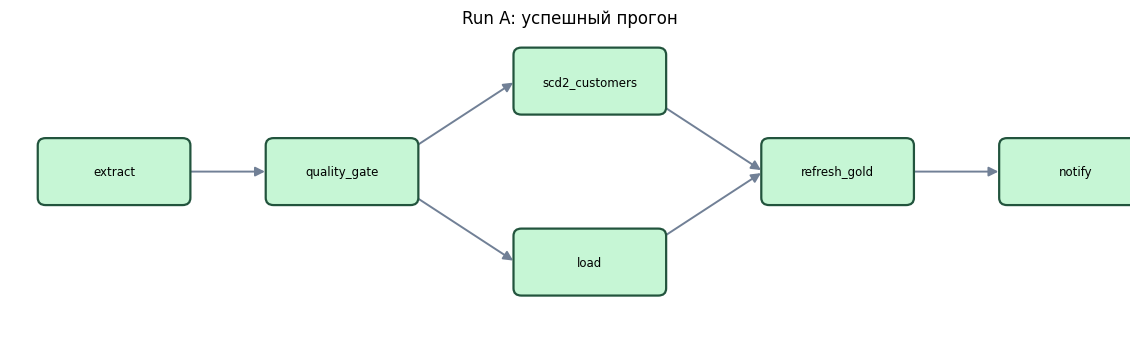

In [13]:
day3 = datetime(2026, 1, 12, 12, 0)
new_orders_day3 = [
    (i, random.randint(1, 5), round(random.uniform(10, 500), 2), day3)
    for i in range(701, 901)
]
cur.executemany(
    "INSERT INTO source_orders (order_id, customer_id, amount, updated_at) VALUES (%s, %s, %s, %s)",
    new_orders_day3,
)

dag = build_orders_dag()
ctx_a = {"customer_changes": [(5, "East", "wholesale", date(2026, 1, 12))]}
print("=== Run A: день 3, чистые данные ===")
state_a = dag.run(ctx_a)
draw_dag_run(state_a, "Run A: успешный прогон")

### Run B — идемпотентный повторный запуск (новых данных нет)

In [14]:
dag_b = build_orders_dag()
print("=== Run B: повторный запуск сразу же, без новых данных ===")
state_b = dag_b.run({})

cur.execute("SELECT COUNT(*) FROM target_orders")
print(f"\nСтрок в target_orders: {cur.fetchone()[0]} (не изменилось — прогон был no-op)")

=== Run B: повторный запуск сразу же, без новых данных ===
  [extract] watermark был 2026-01-12 12:00:00, извлечено строк: 0
  [quality_gate] проверка пройдена (попытка 1)
  [scd2_customers] изменений измерения применено: 0/0
  [load] загружено/обновлено строк: 0
  [refresh_gold] витрина gold_customer_orders обновлена
  [notify] 🟢 пайплайн успешно завершён

Строк в target_orders: 900 (не изменилось — прогон был no-op)


### Run C — "плохой" батч (день 4): пайплайн должен упасть *до* загрузки в gold

=== Run C: день 4, среди данных есть заказ с отрицательной суммой ===
  [extract] watermark был 2026-01-12 12:00:00, извлечено строк: 49
  [quality_gate] ❌ попытка 1/3 упала: нарушение качества данных: есть 1 заказ(ов) с amount <= 0


  [quality_gate] ❌ попытка 2/3 упала: нарушение качества данных: есть 1 заказ(ов) с amount <= 0
  [quality_gate] ❌ попытка 3/3 упала: нарушение качества данных: есть 1 заказ(ов) с amount <= 0
  [scd2_customers] ⏭️  SKIPPED (upstream_failed, trigger_rule=all_success)
  [load] ⏭️  SKIPPED (upstream_failed, trigger_rule=all_success)
  [refresh_gold] ⏭️  SKIPPED (upstream_failed, trigger_rule=all_success)
  [notify] 🔴 ALERT: пайплайн завершился с ошибками в задачах: ['quality_gate', 'scd2_customers', 'load', 'refresh_gold']


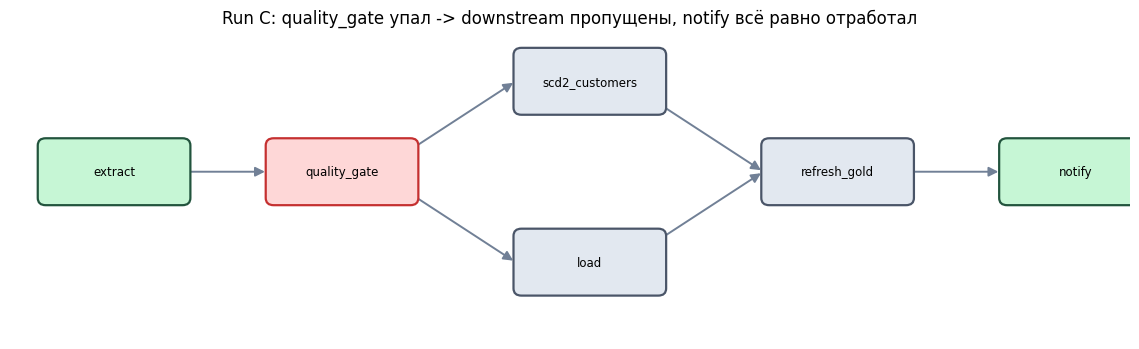


Watermark после Run C: 2026-01-12 12:00:00 (не сдвинулся!)
Строк в target_orders: 900 («плохой» батч НЕ попал в target)


In [15]:
day4 = datetime(2026, 1, 13, 12, 0)
bad_orders_day4 = [(901, 1, -50.0, day4)] + [
    (i, random.randint(1, 5), round(random.uniform(10, 500), 2), day4)
    for i in range(902, 950)
]
cur.executemany(
    "INSERT INTO source_orders (order_id, customer_id, amount, updated_at) VALUES (%s, %s, %s, %s)",
    bad_orders_day4,
)

dag_c = build_orders_dag()
print("=== Run C: день 4, среди данных есть заказ с отрицательной суммой ===")
state_c = dag_c.run({})
draw_dag_run(state_c, "Run C: quality_gate упал -> downstream пропущены, notify всё равно отработал")

print("\nWatermark после Run C:", get_watermark("orders_pipeline"), "(не сдвинулся!)")
cur.execute("SELECT COUNT(*) FROM target_orders")
print("Строк в target_orders:", cur.fetchone()[0], "(«плохой» батч НЕ попал в target)")

Ключевой момент: `quality_gate` упал → `scd2_customers` и `load` получили статус
`UPSTREAM_FAILED` и не выполнились (данные из дня 4 не попали ни в `target_orders`, ни в
`gold`) → но `notify` с `trigger_rule="all_done"` всё равно запустился и прислал бы алерт.
А главное — **watermark не сдвинулся**. Это значит, что пайплайн полностью безопасно
перезапустить в любой момент: он снова возьмёт тот же батч дня 4 (никакого специального
"backfill" не требуется — это и есть весь смысл идемпотентной инкрементальной загрузки).

### Run D — источник поправили, плюс демонстрация retry при временном сбое

=== Run D: батч дня 4 исправлен + симулируем временный сбой источника ===
  [extract] watermark был 2026-01-12 12:00:00, извлечено строк: 49
  [quality_gate] ❌ попытка 1/3 упала: источник временно недоступен (попытка 1)


  [quality_gate] ❌ попытка 2/3 упала: источник временно недоступен (попытка 2)
  [quality_gate] проверка пройдена (попытка 3)
  [scd2_customers] изменений измерения применено: 0/0


  [load] загружено/обновлено строк: 49
  [refresh_gold] витрина gold_customer_orders обновлена
  [notify] 🟢 пайплайн успешно завершён


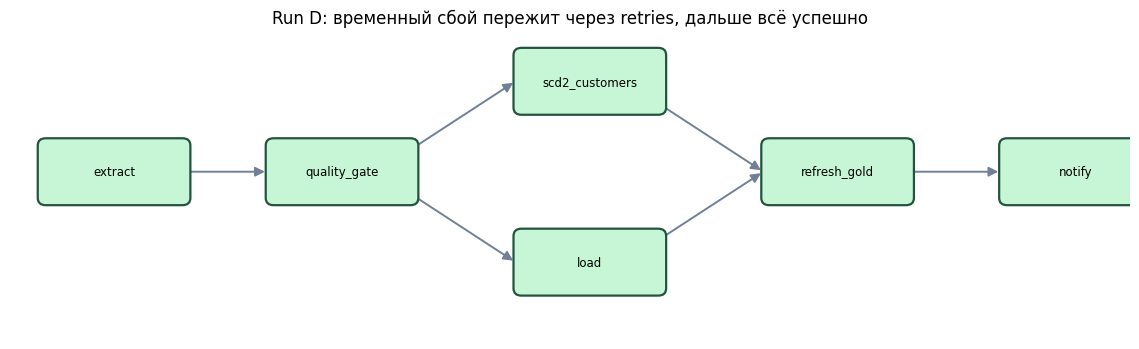


Строк в target_orders: 949 (было 900, стало 900 + 49 = 949)
Watermark после Run D: 2026-01-13 12:00:00


In [16]:
# "Ops-команда" поправила плохую строку прямо в источнике
cur.execute("UPDATE source_orders SET amount = 75.0 WHERE order_id = 901")

dag_d = build_orders_dag()
ctx_d = {"simulate_transient_failure": True}   # первые 2 попытки quality_gate упадут как бы "по сети"
print("=== Run D: батч дня 4 исправлен + симулируем временный сбой источника ===")
state_d = dag_d.run(ctx_d)
draw_dag_run(state_d, "Run D: временный сбой пережит через retries, дальше всё успешно")

cur.execute("SELECT COUNT(*) FROM target_orders")
print(f"\nСтрок в target_orders: {cur.fetchone()[0]} (было 900, стало 900 + 49 = 949)")
print("Watermark после Run D:", get_watermark("orders_pipeline"))

In [ ]:


gold = pd.read_sql("SELECT * FROM gold_customer_orders ORDER BY region, order_month", conn)
gold

C:\Users\raven\AppData\Local\Temp\ipykernel_31972\3868749591.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  gold = pd.read_sql("SELECT * FROM gold_customer_orders ORDER BY region, order_month", conn)


,region,order_month,revenue,orders_cnt
0,East,2026-01-01,96025.40,378
1,North,2026-01-01,49571.14,197
2,West,2026-01-01,96885.34,374


`quality_gate` упал дважды подряд ("временный сбой"), но благодаря `retries=2` третья попытка
отработала — и весь остаток DAG выполнился успешно, включая ранее заблокированный батч дня 4.
Обратите внимание на разницу между Run C и Run D: **постоянная** проблема (реально плохие
данные) не лечится retries — DAG будет падать при каждой попытке, пока данные не поправят.
А **временная** проблема (сеть моргнула, API источника подвис) как раз для retries и придумана.

## 7. Retries, backoff, alerting, SLA

Мы уже увидели retries в действии в Run D. Несколько важных деталей, которые в реальном
Airflow настраиваются на уровне таска или DAG:

* **`retries` + `retry_delay`** — сколько раз и с какой паузой повторить упавший таск
* **Экспоненциальный backoff** (`retry_exponential_backoff=True`) — каждая следующая попытка
  ждёт дольше предыдущей; полезно, если источник "просел" под нагрузкой — резкая серия
  повторов может лишь усугубить проблему
* **`on_failure_callback`** — функция, которая вызывается при окончательном падении таска
  (после исчерпания retries) — обычно шлёт алерт в Slack/PagerDuty
* **SLA (`sla=timedelta(...)`)** — если таск/DAG не уложился в ожидаемое время выполнения,
  Airflow шлёт отдельное уведомление о нарушении SLA — это **не** то же самое, что падение
  таска: таск может успешно завершиться, но слишком поздно (например, к моменту, когда
  BI-дашборд уже открыл менеджер по продажам)

Наш `task_notify` в разделе 6 — упрощённый аналог `on_failure_callback`, только мы вызываем
его явно как последний таск DAG с `trigger_rule="all_done"`, а не как отдельный колбэк.

## 8. Airflow + dbt: разделение оркестрации и трансформации

На практике логику `refresh_gold` из раздела 6 (агрегирующий `SQL`-запрос) редко пишут
прямо в Python-таске Airflow. Устоявшийся паттерн:

* **Airflow отвечает за "когда"** — расписание, зависимости, retries, алерты
* **dbt отвечает за "что"** — сама трансформация данных описывается в `.sql`-файлах с
  Jinja-шаблонами, версионируется в git, имеет встроенные тесты (`dbt test`, по сути
  тот же `validate_orders_batch`, но декларативно) и автоматически строит граф зависимостей
  между моделями по `ref()`

Типичный таск в DAG выглядит так:
```python
from airflow.operators.bash import BashOperator

transform = BashOperator(
    task_id="dbt_run_gold_models",
    bash_command="dbt build --select tag:gold",
)
extract_task >> transform >> notify
```
Так SQL-трансформации получают контроль версий, тесты и lineage-граф "бесплатно" от dbt,
а Airflow не превращается в свалку из сотен разрозненных SQL-строк внутри Python-кода.

## 9. Data-aware scheduling: `Dataset` вместо cron

Классический способ расписания — cron-подобное выражение (`schedule="0 6 * * *"`): DAG
запускается в 6 утра **независимо от того**, готовы ли реально данные, от которых он зависит.
Если апстрим-пайплайн (в терминах Data Mesh — данные другого домена) опаздывает — DAG всё
равно стартует и обработает неполные/устаревшие данные.

Начиная с Airflow 2.4, есть **data-aware scheduling** через `Dataset`: DAG может быть
объявлен как "запускайся, когда обновится вот этот датасет", а не "запускайся по расписанию":
```python
from airflow.datasets import Dataset

orders_dataset = Dataset("postgres://pipelines/target_orders")

# в DAG, который ПРОИЗВОДИТ данные:
load_task = PythonOperator(task_id="load", python_callable=load_orders_upsert,
                            outlets=[orders_dataset])

# в DAG, который ПОТРЕБЛЯЕТ данные — не cron, а триггер по датасету:
downstream_dag = DAG(dag_id="gold_refresh", schedule=[orders_dataset])
```
Это ближе к событийной модели: пайплайн реагирует на факт "данные реально обновились", а не
на условное расписание, которое лишь *предполагает*, что к этому времени данные уже готовы.

## 10. Важные выводы

👉 **Execution date / data interval**: run, появившийся в UI сегодня, почти всегда обрабатывает
данные *за предыдущий* интервал. `catchup` управляет тем, нужно ли досчитывать пропущенное прошлое.

👉 **Идемпотентность = watermark (что уже загружено) + UPSERT (не плодит дубли)**. Без этой пары
любой повторный запуск/retry становится риском задвоить данные.

👉 **SCD Type 1** — перезаписать (история теряется), **Type 2** — версионировать
(`valid_from`/`valid_to`/`is_current`, история сохраняется для расчётов "как было на момент события").

👉 **Trigger rules** — по умолчанию таск ждёт полного успеха родителей (`all_success`); для
уведомлений/cleanup нужен `all_done`, чтобы они срабатывали даже после падения пайплайна.

👉 **Watermark не двигается, пока загрузка не подтверждена успешной** — поэтому упавший
пайплайн безопасно просто перезапустить, специальный backfill для этого не нужен.

👉 **Retries лечат временные сбои, но не лечат плохие данные** — для последних нужен явный
quality gate, который должен падать раньше, чем данные попадут в `target`/`gold`.

👉 На практике связка **Airflow (когда) + dbt (что) + Dataset-scheduling (по готовности данных,
а не по расписанию)** — стандартный стек для оркестрации пайплайнов среднего/крупного масштаба.

## 11. Задания для практики

1. Добавьте в `MiniDAG` trigger rule `"none_failed_min_one_success"` (запуск, если ни один
   родитель не упал, и хотя бы один успешно завершился — например, для случая с
   branching-веткой, где часть родителей осознанно `SKIPPED`).
2. Реализуйте SLA: засеките время выполнения каждого таска в `MiniDAG.run` и печатайте
   предупреждение, если таск выполнялся дольше заданного порога — даже если он завершился успешно.
3. Расширьте `validate_orders_batch` проверкой на аномальные выбросы (например, `amount`,
   отличающийся от медианы батча более чем в 50 раз) и прогоните `dag` на батче с такой аномалией.
4. Напишите функцию `resolve_customer_as_of(customer_id, order_date)`, которая через
   `dim_customers` (Type 2) возвращает регион/сегмент клиента, актуальные **на дату заказа**,
   а не текущие — и используйте её вместо `is_current=True` в `refresh_gold`, чтобы исторические
   агрегаты в `gold_customer_orders` не "переписывались" задним числом при смене региона клиента.